### MDART PAPER: SUPP FIG5

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

In [2]:
group_level_csv_path = "../data/suppfig5/roi_timecourse_group.csv"
plot_df = pd.read_csv(group_level_csv_path)

plot_df_BST_cue = plot_df.loc[
    (plot_df["roi"] == "BNST_p1.00") &
    (plot_df["alignment"] == "cue")
].copy()

plot_df_CE_cue = plot_df.loc[
    (plot_df["roi"] == "CE_p1.00") &
    (plot_df["alignment"] == "cue")
].copy()

def plot_timecourse(
    ax,
    plot_df,
    alignment,
    show_sem=True,
    sem_alpha=0.15,
    colors=None,
    xlim=(-0.5, 8),
    ylim=(-0.15, 0.20)
):
    if colors is None:
        colors = {
            "probability": "#dc006e",
            "outcome": "#000000",
            "risk": "#d98c00",
            "ambiguity": "#9fd3e6",
        }
        
    ax.set_xlim(*xlim)
    ax.set_xticks(np.arange(0, 9, 2))
    ax.set_xticklabels(["0", "2", "4", "6", "8"])
    ax.set_ylim(*ylim)

    ax.axvspan(6.02, 8, color="#c1c5c7", alpha=0.2, zorder=0)

    ax.axhline(0, color="black", linewidth=0.6, zorder=0)
    ax.axvline(0, color="black", linewidth=0.6, zorder=0)

    ax.set_ylabel("Beta estimate", fontsize=8, labelpad=0, fontdict={"family": "Arial"})
    ax.set_xlabel("Time from cue onset (s)", fontsize=8, labelpad=1.5, fontdict={"family": "Arial"})

    ax.tick_params(axis="y", labelsize=6.5, pad=0.5)
    ax.tick_params(axis="x", labelsize=6.5, pad=0.5)
    ax.tick_params(axis="both", which="both", width=0.4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.6)
    ax.spines["left"].set_linewidth(0.6)

    x = plot_df["time_s"].to_numpy()

    # Probability
    if "mean_beta_p_threat_risky" in plot_df.columns:
        y = plot_df["mean_beta_p_threat_risky"].to_numpy()
        ax.plot(x, y, label="Probability", color=colors["probability"], linewidth=0.8)

        if show_sem and "sem_beta_p_threat_risky" in plot_df.columns:
            sem = plot_df["sem_beta_p_threat_risky"].to_numpy()
            ax.fill_between(x, y - sem, y + sem,
                            color=colors["probability"], alpha=sem_alpha, linewidth=0)
            
    # Risk
    if "mean_beta_r_risk_risky" in plot_df.columns:
        y = plot_df["mean_beta_r_risk_risky"].to_numpy()
        ax.plot(x, y, label="Risk", color=colors["risk"], linewidth=0.8)

        if show_sem and "sem_beta_r_risk_risky" in plot_df.columns:
            sem = plot_df["sem_beta_r_risk_risky"].to_numpy()
            ax.fill_between(x, y - sem, y + sem,
                            color=colors["risk"], alpha=sem_alpha, linewidth=0)
            
    # Ambiguity
    if "mean_beta_a_amb_amb" in plot_df.columns:
        y = plot_df["mean_beta_a_amb_amb"].to_numpy()
        ax.plot(x, y, label="Ambiguity", color=colors["ambiguity"], linewidth=0.8)

        if show_sem and "sem_beta_a_amb_amb" in plot_df.columns:
            sem = plot_df["sem_beta_a_amb_amb"].to_numpy()
            ax.fill_between(x, y - sem, y + sem,
                            color=colors["ambiguity"], alpha=sem_alpha, linewidth=0)

    # Outcome
    if "mean_beta_outcome_demeaned" in plot_df.columns:
        y = plot_df["mean_beta_outcome_demeaned"].to_numpy()
        ax.plot(x, y, label="Outcome", color=colors["outcome"], linewidth=0.8)

        if show_sem and "sem_beta_outcome_demeaned" in plot_df.columns:
            sem = plot_df["sem_beta_outcome_demeaned"].to_numpy()
            ax.fill_between(x, y - sem, y + sem,
                            color=colors["outcome"], alpha=sem_alpha, linewidth=0)

    # Outcome-onset window label
    y_textline = 0.14
    y_text = 0.145
    tick_h = 0.01
    x_start = 6.06
    x_end = 7.96

    ax.plot([x_start, x_end], [y_textline, y_textline], color="black", linewidth=0.4)
    ax.plot([x_start, x_start], [y_textline + tick_h, y_textline - tick_h], color="black", linewidth=0.4)
    ax.plot([x_end, x_end], [y_textline + tick_h, y_textline - tick_h], color="black", linewidth=0.4)

    ax.text(
        (x_start + x_end) / 2,
        y_text,
        "jittered\nshock",
        ha="center",
        va="bottom",
        fontsize=6.5,
    )

    leg = ax.legend(
    loc="upper right",
    bbox_to_anchor=(0.33, 1),
    fontsize=6,
    frameon=True,
    framealpha=0.9,
    borderpad=0.2,)

    leg.get_frame().set_linewidth(0.4)
    return ax

In [3]:
def compute_significance_vs_zero(df_subject_level, roi, alignment, predictor_cols, tmin=0.0, tmax=8.0, alpha=0.05):
    """
    One-sample t-test of each predictor's beta against zero across subjects,
    at each timepoint within [tmin, tmax]. P-values from all predictors x all
    timepoints in this window are pooled and FDR-corrected together
    (Benjamini-Hochberg), so the correction reflects the full family of tests
    shown in one figure panel (e.g., all 4 lines in the BST plot, tested
    together, restricted to the reported 0-8 s window).

    Parameters
    ----------
    df_subject_level : pd.DataFrame
        Long subject-level beta timecourse table (one row per subject x time_s).
    roi : str
        Value to filter the "roi" column on (e.g., "BNST_p1.00").
    alignment : str
        Value to filter the "alignment" column on (e.g., "cue").
    predictor_cols : list of str
        Beta column names to test (e.g., ["beta_p_threat_risky", ...]).
    tmin, tmax : float
        Restrict testing/correction to this time window (inclusive), matching
        the reported/plotted range rather than the full extraction window.
    alpha : float
        FDR threshold.

    Returns
    -------
    times : np.ndarray, shape (T,)
        Sorted timepoints within [tmin, tmax].
    sig_masks : dict[str, np.ndarray]
        predictor column -> boolean significance array, shape (T,).
    qvals : dict[str, np.ndarray]
        predictor column -> FDR-corrected q-values, shape (T,).
    """
    df_panel = df_subject_level.loc[
        (df_subject_level["roi"] == roi)
        & (df_subject_level["alignment"] == alignment)
        & (df_subject_level["time_s"] >= tmin - 1e-9)
        & (df_subject_level["time_s"] <= tmax + 1e-9)
    ]

    times = np.sort(df_panel["time_s"].unique())

    raw_pvals = {}
    for col in predictor_cols:
        pvals = []
        for t in times:
            vals = df_panel.loc[df_panel["time_s"] == t, col].dropna().to_numpy()
            _, p = stats.ttest_1samp(vals, popmean=0.0)
            pvals.append(p)
        raw_pvals[col] = np.array(pvals)

    # Pool all predictors x all timepoints into one FDR family for this panel
    pooled = np.concatenate([raw_pvals[col] for col in predictor_cols])
    _, qvals_pooled, _, _ = multipletests(pooled, alpha=alpha, method="fdr_bh")

    n_t = len(times)
    sig_masks = {}
    qvals = {}
    for i, col in enumerate(predictor_cols):
        seg = qvals_pooled[i * n_t:(i + 1) * n_t]
        qvals[col] = seg
        sig_masks[col] = seg < alpha

    return times, sig_masks, qvals


def restrict_significance_to_positive(times, sig_masks, group_df, mean_col_map):
    """
    AND each predictor's FDR significance mask with (mean beta > 0) at each
    timepoint, so only points where the plotted line is above zero are
    marked significant. Uses the group-level mean beta timecourse, i.e. the
    same values drawn by plot_timecourse.

    Parameters
    ----------
    times : np.ndarray
        Timepoints corresponding to sig_masks, as returned by
        compute_significance_vs_zero.
    sig_masks : dict[str, np.ndarray]
        Key -> boolean significance array (e.g. output of compute_significance_vs_zero
        after remapping columns to plot keys).
    group_df : pd.DataFrame
        Group-level timecourse table (one row per time_s) containing the
        mean beta columns, e.g. plot_df_BST_cue.
    mean_col_map : dict[str, str]
        sig_masks key -> group_df mean beta column name.

    Returns
    -------
    dict[str, np.ndarray]
        Same keys as sig_masks, with each mask ANDed against (mean beta > 0).
    """
    group_by_time = group_df.set_index("time_s")

    masked = {}
    for key, mask in sig_masks.items():
        mean_vals = group_by_time.loc[times, mean_col_map[key]].to_numpy()
        masked[key] = np.asarray(mask) & (mean_vals > 0)
    return masked


def _contiguous_runs(mask):
    """Return list of (start_idx, end_idx) inclusive index pairs for contiguous True runs in a boolean array."""
    runs = []
    start = None
    for i, val in enumerate(mask):
        if val and start is None:
            start = i
        elif not val and start is not None:
            runs.append((start, i - 1))
            start = None
    if start is not None:
        runs.append((start, len(mask) - 1))
    return runs


def add_significance_strips(ax, times, sig_masks, colors, y0=-0.088, row_height=-0.012, linewidth=1):
    """
    Draw one thin horizontal row per predictor beneath the x-axis, filled
    wherever that predictor's FDR-corrected beta differs from zero.

    Each significant timepoint is treated as covering a half-timestep-wide
    tile, so consecutive significant timepoints merge into one continuous
    stripe with no visual gaps, while true breaks in significance (a
    non-significant timepoint in between) still show as a gap. Isolated
    single significant timepoints still render as a small visible tick.

    sig_masks keys must match the keys used in `colors` (e.g.,
    "probability", "risk", "ambiguity", "outcome").
    """
    dt = np.median(np.diff(times)) if len(times) > 1 else 0.1

    for i, key in enumerate(sig_masks):
        mask = np.asarray(sig_masks[key])
        y = y0 + i * row_height

        for start_idx, end_idx in _contiguous_runs(mask):
            x_start = times[start_idx] - dt / 2
            x_end = times[end_idx] + dt / 2
            ax.plot(
                [x_start, x_end], [y, y],
                color=colors[key], linewidth=linewidth,
                solid_capstyle="butt", clip_on=False,
            )

In [4]:
subject_level_csv_path = "../data/suppfig5/roi_timecourse_subject.csv"
df_subject_level = pd.read_csv(subject_level_csv_path)

predictor_cols = ["beta_p_threat_risky", "beta_r_risk_risky", "beta_a_amb_amb", "beta_outcome_demeaned"]
col_to_key = {
    "beta_p_threat_risky": "probability",
    "beta_r_risk_risky": "risk",
    "beta_a_amb_amb": "ambiguity",
    "beta_outcome_demeaned": "outcome",
}
mean_col_map = {
    "probability": "mean_beta_p_threat_risky",
    "risk": "mean_beta_r_risk_risky",
    "ambiguity": "mean_beta_a_amb_amb",
    "outcome": "mean_beta_outcome_demeaned",
}
sig_colors = {
    "probability": "#dc006e",
    "outcome": "#000000",
    "risk": "#d98c00",
    "ambiguity": "#9fd3e6",
}

times_bst, sig_masks_bst_raw, qvals_bst = compute_significance_vs_zero(
    df_subject_level, roi="BNST_p1.00", alignment="cue", predictor_cols=predictor_cols
)
sig_masks_bst = {col_to_key[c]: m for c, m in sig_masks_bst_raw.items()}
sig_masks_bst = restrict_significance_to_positive(times_bst, sig_masks_bst, plot_df_BST_cue, mean_col_map)

times_ce, sig_masks_ce_raw, qvals_ce = compute_significance_vs_zero(
    df_subject_level, roi="CE_p1.00", alignment="cue", predictor_cols=predictor_cols
)
sig_masks_ce = {col_to_key[c]: m for c, m in sig_masks_ce_raw.items()}
sig_masks_ce = restrict_significance_to_positive(times_ce, sig_masks_ce, plot_df_CE_cue, mean_col_map)

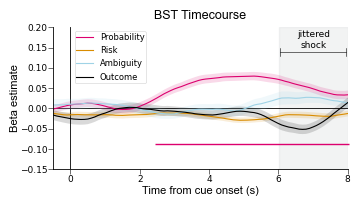

In [5]:
import os
output_dir = "../outputs/figures"  # created if missing
os.makedirs(output_dir, exist_ok=True)
fig, ax = plt.subplots(figsize=(90 / 25.4, 2))
plot_timecourse(ax, plot_df_BST_cue , alignment="cue")
add_significance_strips(ax, times_bst, sig_masks_bst, colors=sig_colors)
ax.set_title("BST Timecourse", fontdict={"family": "Arial"}, fontsize=9)
plt.tight_layout(pad=0.5)
fig.savefig(os.path.join(output_dir, "timecourse_BST_cue_mm.pdf"))
plt.show()

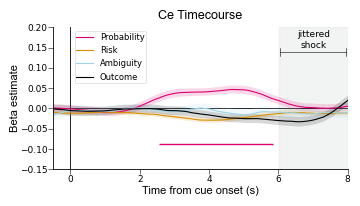

In [6]:
fig, ax = plt.subplots(figsize=(90 / 25.4, 2))
plot_timecourse(ax, plot_df_CE_cue , alignment="cue")
add_significance_strips(ax, times_ce, sig_masks_ce, colors=sig_colors)
ax.set_title("Ce Timecourse", fontdict={"family": "Arial"}, fontsize=9)
plt.tight_layout(pad=0.5)
fig.savefig(os.path.join(output_dir, "timecourse_CE_cue.pdf"))
plt.show()